In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json

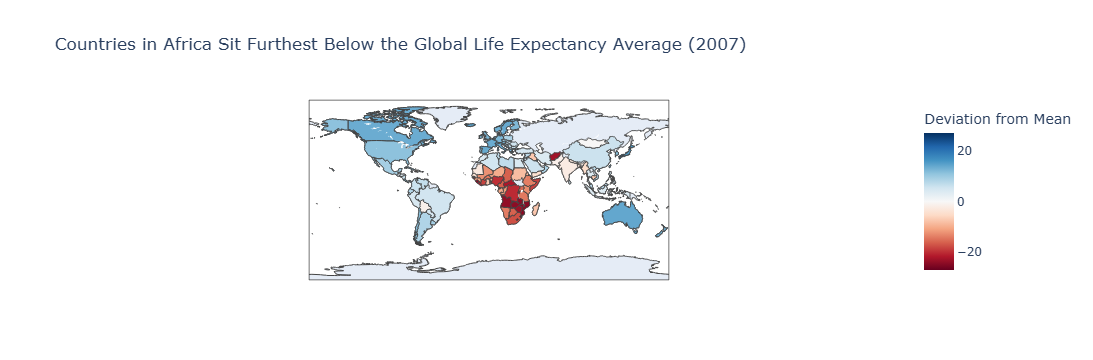

In [11]:


# Load Gapminder data
gm = px.data.gapminder()

# Filter for 2007
gm_2007 = gm[gm['year'] == 2007].copy()

# Compute global mean life expectancy
global_mean = gm_2007['lifeExp'].mean()

# Compute deviation from global mean
gm_2007['lifeExp_diff'] = gm_2007['lifeExp'] - global_mean

# Find region furthest below average
lowest_region = (
    gm_2007.groupby('continent')['lifeExp_diff']
    .mean()
    .idxmin()
)

# Build choropleth
fig = px.choropleth(
    gm_2007,
    locations='iso_alpha',
    color='lifeExp_diff',
    hover_name='country',
    hover_data={
        'lifeExp': ':.1f',
        'lifeExp_diff': ':.1f',
        'iso_alpha': False
    },
    color_continuous_scale='RdBu',
    color_continuous_midpoint=0,
    title=f'Countries in Africa Sit Furthest Below the Global Life Expectancy Average (2007)'
)

fig.update_layout(
    coloraxis_colorbar_title='Deviation from Mean'
)

fig.show()

In [8]:
### Design Decisions

#I used `px.choropleth` because the dataset already contains ISO country codes and does not require a tile-based map,
#I used a diverging colour scale (`RdBu`) because the data represents deviation from a global average:
#  negative values = below average
# positive values = above average
# The scale is centred at zero to clearly separate countries above and below the world mean.

In [9]:
## Task 2 — Design decisions

#GeoJSON source:
#https://raw.githubusercontent.com/PublicaMundi/MappingAPI/master/data/geojson/us-states.json

#Chart type chosen:
#I chose `px.choropleth` because the map uses standard geographic boundaries and does not require a Mapbox basemap.

#Colour scale chosen:
# I used a **sequential colour scale** because population density only varies from low to high values and does not have a meaningful midpoint like positive/negative deviation data.

{'name': 'Afghanistan'}


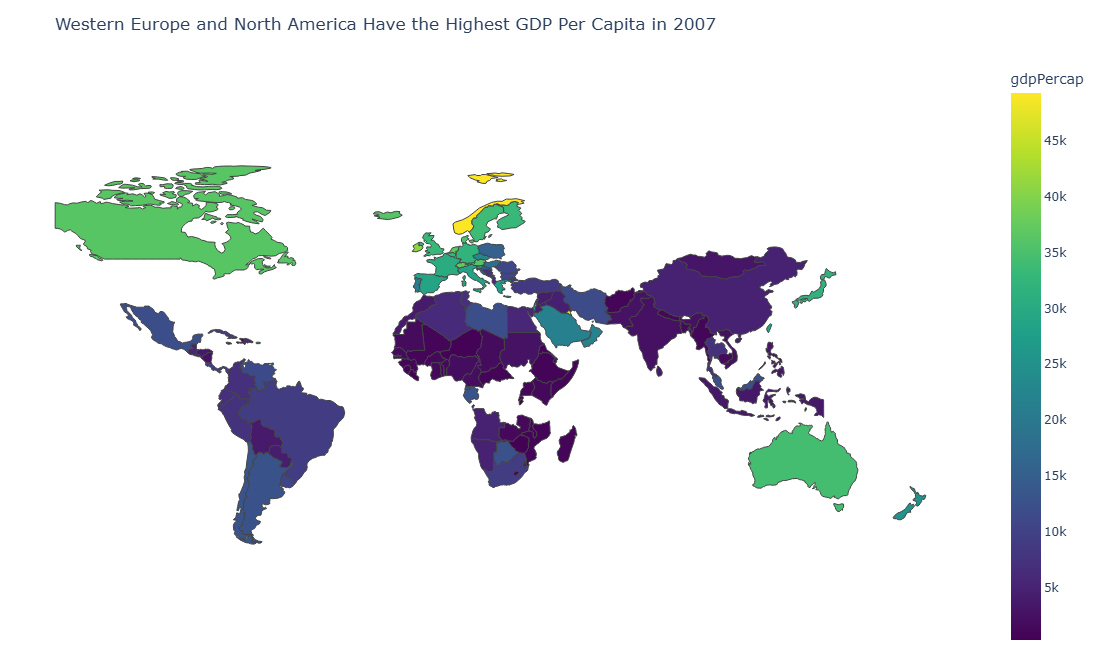

In [13]:

import urllib.request

# Gapminder 2007
gm = px.data.gapminder()
gm_2007 = gm[gm["year"] == 2007]

# World countries GeoJSON
url = "https://raw.githubusercontent.com/johan/world.geo.json/master/countries.geo.json"

with urllib.request.urlopen(url) as response:
    world_geojson = json.load(response)

# Inspect properties
print(world_geojson["features"][0]["properties"])

# Choropleth
fig = px.choropleth(
    gm_2007,
    geojson=world_geojson,
    locations="country",
    featureidkey="properties.name",
    color="gdpPercap",
    hover_name="country",
    hover_data={
        "lifeExp": True,
        "pop": ":,.0f",
        "gdpPercap": ":,.0f"
    },
    color_continuous_scale="Viridis",
    title="Western Europe and North America Have the Highest GDP Per Capita in 2007"
)

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    margin=dict(l=0, r=0, t=60, b=0),
    height=650
)

fig.show()